# Punto 1

## 1. Definición del Problema
El objetivo de este algoritmo genético es encontrar el valor de $x$ que maximiza la siguiente función objetivo:
$$f(x) = x \sin(10 \pi x) + 1$$
Sujeto a la restricción de que el valor real se encuentre en el intervalo $x \in [0,1]$.

## 2. Metodología del Algoritmo Genético (AGS)
Siguiendo los pasos para el diseño de un Algoritmo Genético Simple (AGS):
*   **Representación:** Utilizaremos un cromosoma binario (lista de 0s y 1s) de longitud $l$ para representar el espacio de búsqueda. Un genotipo binario se decodificará a un fenotipo real (valor $x$).
*   **Función de Aptitud (Fitness):** Como buscamos maximizar, y dado que la función arroja valores positivos en el rango $[0,1]$, la aptitud de cada cromosoma será directamente el valor evaluado en $f(x)$.
*   **Operadores Genéticos:** Se implementarán los tres operadores clásicos:
    *   **Selección:** Mediante el método de la ruleta, dando mayor probabilidad a los individuos más aptos.
    *   **Cruce:** Cruce simple en un punto elegido aleatoriamente.
    *   **Mutación:** Inversión de bit (de 0 a 1 o viceversa) con una probabilidad $p_m$ baja para evitar óptimos locales.
*   **Criterio de Parada:** El algoritmo se detendrá tras un número fijo de generaciones $M$.

In [1]:
# Importación de librerías necesarias
import random
import math
import matplotlib.pyplot as plt

## 3. Generación de Población y Decodificación

Para iniciar el algoritmo, necesitamos generar una población aleatoria de cromosomas. Cada cromosoma es una lista de bits de longitud $l$. 

Una vez generados, debemos decodificarlos. La decodificación convierte el contenido binario del cromosoma (genotipo) en un valor real dentro del espacio de soluciones (fenotipo). Para mapear el valor binario al intervalo $[0, 1]$, usamos la proporción del valor decimal respecto al valor máximo posible ($2^l - 1$).

In [2]:
def genera(l, K):
    """
    Genera aleatoriamente la población inicial.
    l: longitud del cromosoma (número de bits).
    K: tamaño de la población.
    """
    # Genera K listas de l elementos, donde cada elemento es 0 o 1
    pob = [[random.randint(0, 1) for _ in range(l)] for _ in range(K)]
    return pob

def decodifica(crom, l):
    """
    Convierte la cadena binaria en un valor real en el rango [0, 1].
    """
    xi = 0.0  # Límite inferior del dominio
    xf = 1.0  # Límite superior del dominio
    
    # Se calcula el valor máximo que puede tener un binario de longitud l
    Max = (2 ** l) - 1 
    
    # Conversión de binario a decimal
    cromPot = [crom[i] * (2 ** (l - i - 1)) for i in range(l)]
    valorDecimal = sum(cromPot)
    
    # Mapeo al intervalo [xi, xf]
    valDeco = ((xf - xi) / Max) * valorDecimal + xi
    return valDeco

## 4. Función Objetivo y Evaluación de Aptitud

La función de aptitud dictamina qué tan buena es una solución. Primero evaluamos la ecuación matemática. Luego, calculamos la contribución de la aptitud de cada cromosoma respecto a la aptitud total de la población; esto nos dará la probabilidad de selección de cada individuo.

In [3]:
def ecuacion(x):
    """
    Función matemática a maximizar: f(x) = x * sin(10 * pi * x) + 1
    """
    return x * math.sin(10 * math.pi * x) + 1

def eval_apt(pob, l):
    """
    Evalúa la aptitud de toda la población y calcula la probabilidad de selección.
    Retorna la lista de probabilidades, la mejor aptitud y el mejor cromosoma de la generación.
    """
    apt_crom = []
    apt_pob = 0
    mejor_aptitud = -1
    mejor_cromosoma = None
    
    for crom in pob:
        x = decodifica(crom, l)
        apt = ecuacion(x)
        apt_pob += apt
        apt_crom.append(apt)
        
        # Guardamos el mejor de la generación
        if apt > mejor_aptitud:
            mejor_aptitud = apt
            mejor_cromosoma = crom
            
    # Calculamos la probabilidad de cada cromosoma de ser seleccionado (Método de la Ruleta)
    probab = []
    for apt in apt_crom:
        prob_crom = apt / apt_pob if apt_pob > 0 else 0
        probab.append(prob_crom)
        
    return probab, mejor_aptitud, mejor_cromosoma

## 5. Operadores Genéticos: Selección, Cruce y Mutación

*   **Selección:** Se emplea una variante del método de la ruleta. Se utiliza la probabilidad de cada individuo para decidir si pasa a la lista de padres de la siguiente generación. 
*   **Cruce:** Se escoge un punto aleatorio $pt$ entre $1$ y $l-1$, y se intercambian los segmentos de dos padres consecutivos para generar dos hijos.
*   **Mutación:** Basados en la probabilidad $p_m$, se invierten ciertos bits. En lugar de iterar bit por bit, calculamos cuántas mutaciones deberían ocurrir en el bloque total de genes para ahorrar cómputo.

In [4]:
def seleccion(pob, probab):
    j = 0
    K = len(pob)
    limite = 2 * max(probab) if probab else 0
    pob_nueva = []
    
    # Búsqueda de los mejores individuos simulando el giro de la ruleta
    while j < K:
        i = 0
        while i < K:
            aleat = random.uniform(0, limite)
            if probab[i] > aleat:
                pob_nueva.append(pob[i]) # Se selecciona el individuo i
                j += 1
                if j >= K:
                    break
            i += 1
    return pob_nueva

def cruce(pob_nueva):
    i = 0
    K = len(pob_nueva)
    hijos = []
    
    while i < K - 1:
        crom1 = pob_nueva[i]
        crom2 = pob_nueva[i+1]
        
        # Cruce simple en un punto escogido aleatoriamente
        pt = random.randint(1, len(crom1) - 1)
        hijo1 = crom1[:pt] + crom2[pt:]
        hijo2 = crom2[:pt] + crom1[pt:]
        
        hijos.append(hijo1)
        hijos.append(hijo2)
        i += 2
        
    # En caso de que la población sea impar, el último pasa sin cruzarse
    if len(hijos) < K:
        hijos.append(pob_nueva[-1])
        
    return hijos

def mutacion(hijos, p_mut, l):
    K = len(hijos)
    totalbits = K * l 
    
    # Se calcula el número esperado de mutaciones
    if p_mut > 0:
        segmento = 1 / p_mut 
        n_mutaciones = int(totalbits / segmento)
        i = 0 
        while i < n_mutaciones: 
            muta = random.randint(0, totalbits - 1)
            x = math.floor(muta / l) # Índice del cromosoma
            y = muta % l             # Índice del gen (bit)
            
            # Se cambia 0 por 1 o viceversa
            hijos[x][y] = 1 if hijos[x][y] == 0 else 0 
            i += 1
            
    return hijos

## 6. Algoritmo Principal y Ejecución

La rutina principal integra todos los procedimientos definidos. Se ejecutará un ciclo `while` repetido $M$ veces (número de generaciones). Almacenaremos el historial de la mejor aptitud por generación para poder graficar la convergencia del algoritmo, lo cual nos ayuda a definir si exploramos bien el espacio de búsqueda.

Búsqueda finalizada.
Mejor valor encontrado de x: 0.851228
Valor máximo de f(x): 1.850595


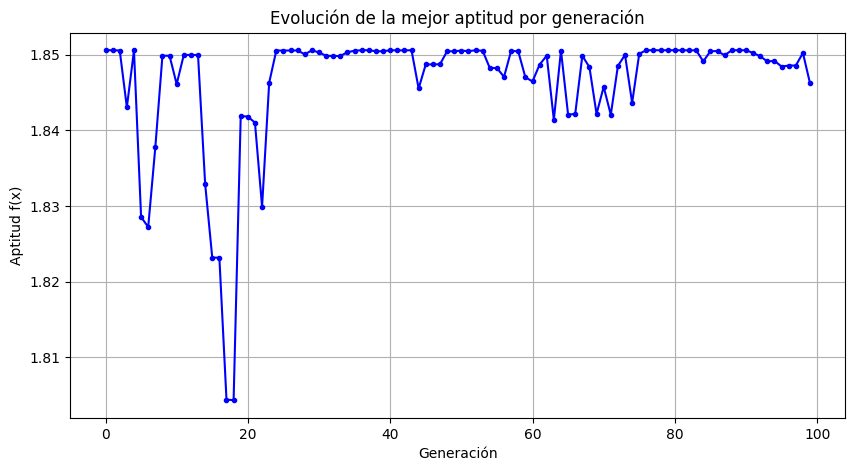

In [5]:
def Alg_Genetico(l, M, K, p_mut):
    # Generación de la población inicial
    pob = genera(l, K) 
    
    historial_aptitud = []
    mejor_x_global = 0
    mejor_aptitud_global = -1
    
    i = 0
    while i < M:
        # Evaluación
        probab, mejor_aptitud, mejor_cromosoma = eval_apt(pob, l)
        historial_aptitud.append(mejor_aptitud)
        
        # Rastreo del mejor histórico global
        if mejor_aptitud > mejor_aptitud_global:
            mejor_aptitud_global = mejor_aptitud
            mejor_x_global = decodifica(mejor_cromosoma, l)
            
        # Operadores Genéticos
        n_pob = seleccion(pob, probab)
        hijos = cruce(n_pob)
        pob = mutacion(hijos, p_mut, l)
        
        i += 1
        
    return historial_aptitud, mejor_x_global, mejor_aptitud_global

# --- PARÁMETROS DE EJECUCIÓN ---
l_bits = 20        # Resolución del cromosoma (a mayor longitud, mayor precisión)
K_pob = 50         # Tamaño de la población
M_gen = 100        # Número de generaciones (Criterio de parada)
p_mut = 0.05       # Probabilidad de mutación (5%)

# Ejecutar el algoritmo
historial, mejor_x, max_f = Alg_Genetico(l_bits, M_gen, K_pob, p_mut)

print(f"Búsqueda finalizada.")
print(f"Mejor valor encontrado de x: {mejor_x:.6f}")
print(f"Valor máximo de f(x): {max_f:.6f}")

# --- GRÁFICA DE CONVERGENCIA ---
plt.figure(figsize=(10, 5))
plt.plot(range(M_gen), historial, marker='.', color='b')
plt.title('Evolución de la mejor aptitud por generación')
plt.xlabel('Generación')
plt.ylabel('Aptitud f(x)')
plt.grid(True)
plt.show()

## 7. Visualización de la Función Objetivo y el Óptimo Encontrado

Para comprobar visualmente la efectividad del Algoritmo Genético, graficaremos la función matemática original en todo su dominio empleando la librería `numpy`. Luego, superpondremos un marcador en las coordenadas `(mejor_x, max_f)` correspondientes al fenotipo del mejor individuo (el más apto) encontrado tras la evolución de las generaciones.

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\tique\AppData\Local\Temp\ipykernel_17860\1727705258.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_vals, y_vals, label='$f(x) = x \sin(10\pi x) + 1$', color='green', linewidth=2)


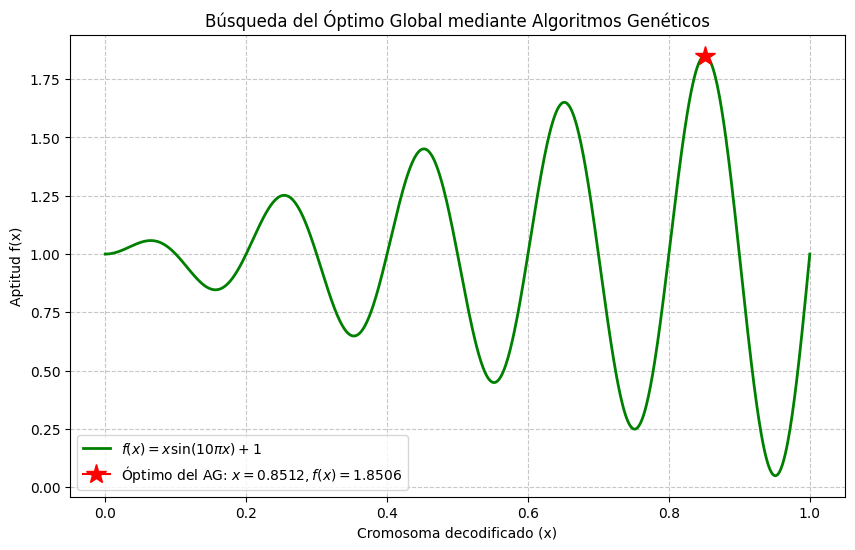

In [6]:
# Importamos numpy para generar fácilmente un arreglo de puntos y evaluar la función
import numpy as np

# Generamos 1000 puntos espaciados uniformemente en el intervalo [0, 1] para una curva suave
x_vals = np.linspace(0, 1, 1000)

# Evaluamos la función f(x) para cada punto empleando operaciones vectorizadas de numpy
y_vals = x_vals * np.sin(10 * np.pi * x_vals) + 1

# Configuración de la figura
plt.figure(figsize=(10, 6))

# Graficamos la función original de fondo
plt.plot(x_vals, y_vals, label='$f(x) = x \sin(10\pi x) + 1$', color='green', linewidth=2)

# Superponemos el punto óptimo encontrado por el Algoritmo Genético
# Usamos una estrella roja grande para que destaque fácilmente
plt.plot(mejor_x, max_f, marker='*', markersize=15, color='red', 
         label=f'Óptimo del AG: $x={mejor_x:.4f}, f(x)={max_f:.4f}$')

# Etiquetas y formato visual
plt.title('Búsqueda del Óptimo Global mediante Algoritmos Genéticos')
plt.xlabel('Cromosoma decodificado (x)')
plt.ylabel('Aptitud f(x)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar la gráfica
plt.show()